# Time Series Analysis: Walmart Sales Trends & Seasonality

## Objective
The purpose of this phase is to analyze **Walmart’s total sales performance over time** by aggregating sales across all stores.  
Unlike prior phases that focused on **store-level performance and volatility**, this section evaluates **portfolio-level trends**, including seasonality, growth, and structural changes in sales behavior.

---

## Key Business Questions
This analysis seeks to answer the following questions:

1. **How do Walmart’s total sales evolve over time?**  
   - Are there clear upward or downward trends across the observed period?

2. **Is there evidence of seasonality in Walmart’s sales?**  
   - Do certain months or periods consistently outperform others?
   - Are holiday effects observable?

3. **How volatile are aggregate sales compared to store-level volatility?**  
   - Does aggregation smooth risk observed at the store level?

4. **Are there structural breaks or anomalies in sales trends?**  
   - Sudden spikes or drops that may reflect macroeconomic or operational factors

5. **How does week-over-week or month-over-month growth behave over time?**  
   - Are growth rates stable, cyclical, or declining?
___

## Methodology & Data Preparation

To evaluate trends and growth behavior, monthly sales were aggregated using SQL.
Month-over-month changes and growth rates were computed to support trend and
anomaly analysis.

In [53]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [54]:
# let us establish a connection to a database
conn = sqlite3.connect('..\db\walmart.db')


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\david\AppData\Local\Temp\ipykernel_5960\2901863177.py:2: SyntaxWarning: invalid escape sequence '\d'
  conn = sqlite3.connect('..\db\walmart.db')


In [67]:
q1 =pd.read_sql("""
WITH monthly_sales AS (
SELECT 
        strftime('%Y-%m',date) AS Months,
        SUM(Weekly_Sales) as Total_Sales
FROM walmart_sales
GROUP BY 1)

SELECT
        Months,
        Total_Sales,
        (Total_Sales - LAG(Total_Sales) OVER ( ORDER BY Months)) as MoM_Change,
        (Total_Sales -LAG(Total_Sales) OVER (ORDER BY Months))
            / NULLIF(LAG(Total_Sales) OVER (ORDER BY Months),0) *100 AS MoM_growth_pct
FROM monthly_sales
GROUP BY 1
""", 
conn
)
q1.head(10)

,Months,Total_Sales,MoM_Change,MoM_growth_pct
0,2010-02,1.903330e+08,NaN,NaN
1,2010-03,1.819198e+08,-8413180.54,-4.420243
2,2010-04,2.314124e+08,49492565.55,27.205705
3,2010-05,1.867109e+08,-44701433.71,-19.316787
4,2010-06,1.922462e+08,5535238.02,2.964603
5,2010-07,2.325801e+08,40333953.62,20.980368
6,2010-08,1.876401e+08,-44940015.09,-19.322380
7,2010-09,1.772679e+08,-10372214.52,-5.527717
8,2010-10,2.171618e+08,39893927.65,22.504880
9,2010-11,2.028534e+08,-14308453.88,-6.588844


In [56]:
q2 = pd.read_sql("""
SELECT
        strftime('%m', date) AS Month,
        AVG(Weekly_Sales) AS Avg_Sales
FROM walmart_sales
GROUP BY Month
ORDER BY Month
""",
conn)
q2.head()

,Month,Avg_Sales
0,01,14126.075111
1,02,16008.779217
2,03,15416.657597
3,04,15650.338357
4,05,15776.337202


### Volatility Computation
Store level volatility was quantified using the coefficient of variation (CV) which was computed as the ratio of the standard deviation to the average of weekly sales.


In [57]:
store_summary = pd.read_csv('..\data\processed\store_summary.csv')
store_summary.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\david\AppData\Local\Temp\ipykernel_5960\1406465820.py:1: SyntaxWarning: invalid escape sequence '\d'
  store_summary = pd.read_csv('..\data\processed\store_summary.csv')


,Store,Total_Sales,Avg_Weekly_Sales,STD_Weekly_Sales,CV,Decline_Sales_Count
0,1,2.224028e+08,1.555795e+06,156031.394350,0.100290,80
1,2,2.753824e+08,1.926818e+06,238698.748076,0.123882,80
2,3,5.758674e+07,4.030476e+05,46405.695032,0.115137,78
3,4,2.995440e+08,2.095075e+06,265591.469067,0.126769,66
4,5,4.547569e+07,3.183279e+05,38052.255525,0.119538,69


### Anomaly Detection Using Z-Score
We will be observing the 33 month period for any spikes/anomalies using z-score analysis. By observing and flagging month-over-month growth that deviate too far from the mean, we can understand which months behaved unusually.

In [58]:
q4 = q1[['Months','MoM_growth_pct']]
q4['MoM_growth_pct_mean'] = q4['MoM_growth_pct'].mean()
q4['MoM_growth_pct_STD']= q4['MoM_growth_pct'].std()
q4['Z_score'] = (q4['MoM_growth_pct'] - q4['MoM_growth_pct_mean']) / q4['MoM_growth_pct_STD']
q4.head()

C:\Users\david\AppData\Local\Temp\ipykernel_5960\3070910924.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q4['MoM_growth_pct_mean'] = q4['MoM_growth_pct'].mean()


,Months,MoM_growth_pct,MoM_growth_pct_mean,MoM_growth_pct_STD,Z_score
0,2010-02,NaN,2.438068,22.308012,NaN
1,2010-03,-4.420243,2.438068,22.308012,-0.307437
2,2010-04,27.205705,2.438068,22.308012,1.110258
3,2010-05,-19.316787,2.438068,22.308012,-0.975204
4,2010-06,2.964603,2.438068,22.308012,0.023603


### Metrics Constructed
The following metrics are computed:

- **Total Sales (Monthly / Weekly)**
- **Period-over-Period Change**
  - Month-over-Month (MoM)
  - Week-over-Week (WoW)
- **Growth Rate (%)**
---

## Assumptions & Design Decisions
- Store-level differences are intentionally abstracted away to focus on overall company performance.
- Aggregation via SUM is used to preserve scale and revenue impact.
- Store summary KPIs remain frozen and are not reused for trend analysis.
---

## Exploratory Analysis

### Time Series Visualization
- Line charts are used to visualize:
  - Total sales over time
  - Smoothed trends (rolling averages)
- Year-over-year comparisons are used to validate seasonality.

## Q1. How Do Walmart’s Total Sales Evolve Over Time?

This section examines aggregate monthly sales to identify long-term trends and
directional movement over the observed period.

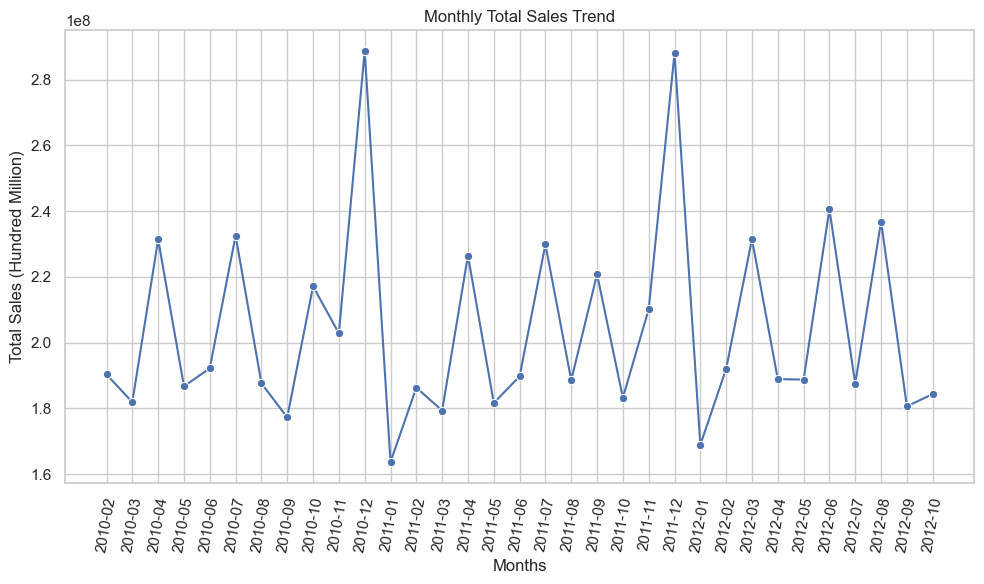

In [73]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
# Total Sales
sns.lineplot(
    data=q1,
    x="Months",
    y="Total_Sales",
    marker="o"
)
plt.title("Monthly Total Sales Trend")
plt.ylabel("Total Sales (Hundred Million)")
plt.xticks(rotation=80, ha="center")
plt.tight_layout()
plt.show()

**Insight:** 
Over the thirty-three observed months, we notice a total sales spike every December followed by a drastic decline in January. Despite these extremerties, the total sales behave in an expected fluctuation throughout the year.

This cyclical nature suggests total sales are heavily influenced by seasonal times and potentially promotional sales.

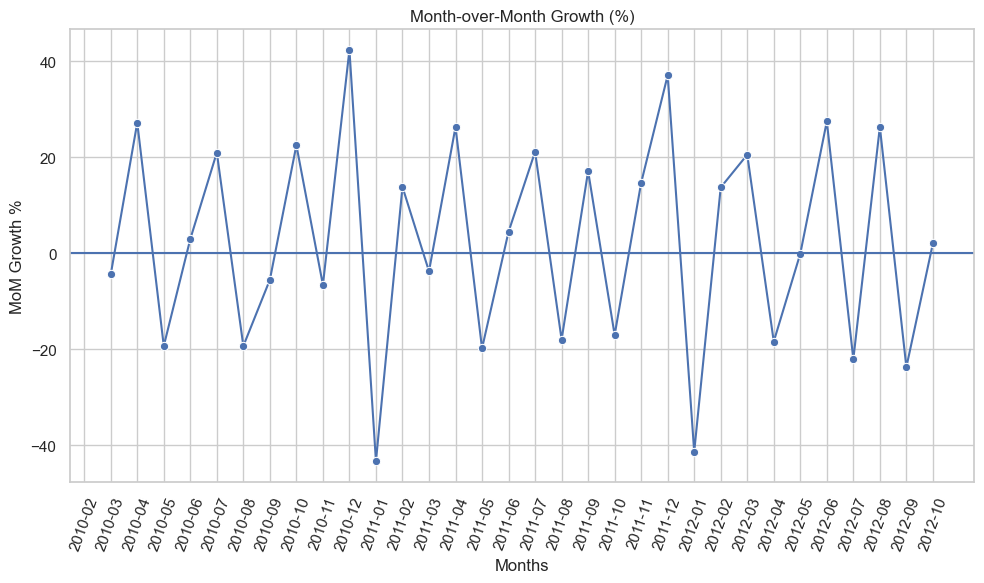

In [71]:
# MoM Growth %
plt.figure(figsize=(10,6))
sns.lineplot(
    data=q1,
    x="Months",
    y="MoM_growth_pct",
    marker="o"
)
plt.axhline(0)
plt.title("Month-over-Month Growth (%)")
plt.ylabel("MoM Growth %")

plt.xticks(rotation=70, ha="center")
plt.tight_layout()
plt.show() 

**Insight:**

Month-over-month growth dynamics reinforce the patterns observed in aggregate sales trends. While growth rates exhibit sharp expansions and contractions, the series demonstrates layered behavior characterized by short-term recovery phases embedded within broader mean-reverting stability.

Following periods of elevated holiday and promotional sales, growth temporarily declines as demand normalizes before stabilizing and recovering ahead of subsequent seasonal peaks. This recurring shock–recovery cycle indicates that fluctuations are primarily driven by predictable retail seasonality rather than structural deterioration in business performance.

## Q2. Is There Evidence of Seasonality in Walmart’s Sales?

Average sales by calendar month are analyzed to identify recurring seasonal
patterns across the observed period.

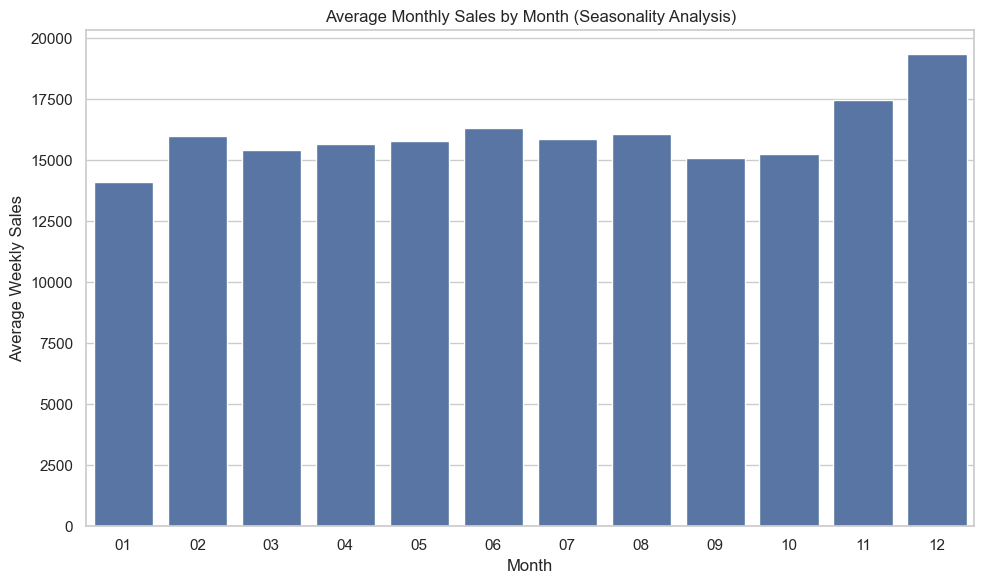

In [61]:
plt.figure(figsize=(10,6))
sns.barplot(
    data = q2,
    x ='Month',
    y ='Avg_Sales'
)
plt.title('Average Monthly Sales by Month (Seasonality Analysis)')
plt.ylabel('Average Weekly Sales')
plt.tight_layout()
plt.show()

**Insight:**
Certain months outperform others which suggests seasonal effects are likely driven by holidays and promitional cycles.

## Q3. How volatile are stores’ total weekly revenues relative to their average performance?

This section compares volatility at the store level with aggregated sales behavior
to assess whether aggregation smooths individual store risk.

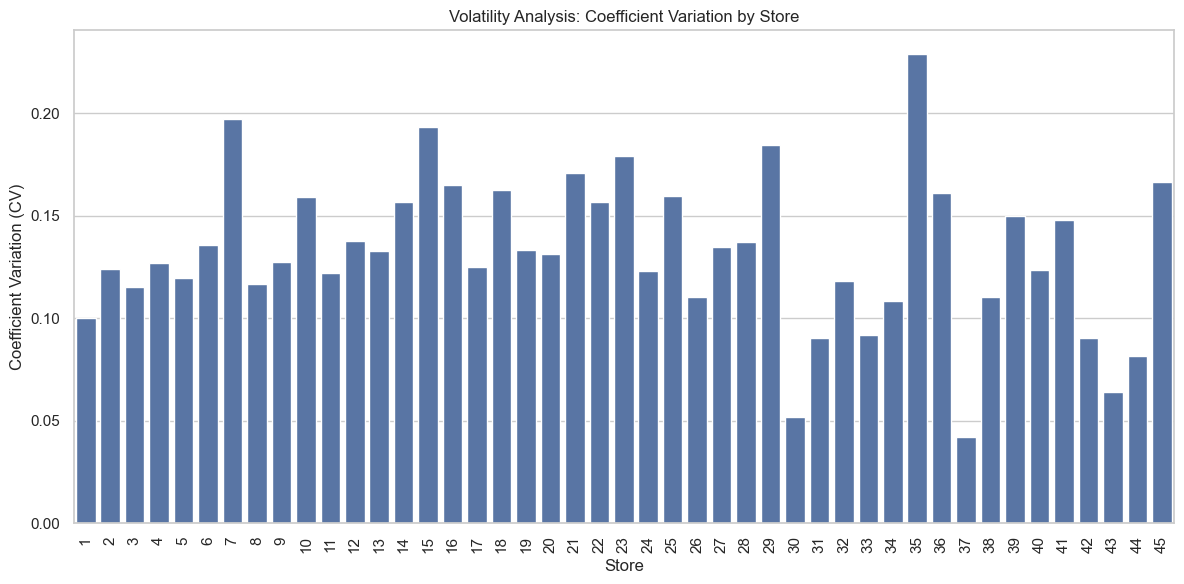

In [62]:
plt.figure(figsize=(12,6))
sns.barplot(
    data= store_summary,
    x ='Store',
    y ='CV'
)
plt.title('Volatility Analysis: Coefficient Variation by Store')
plt.ylabel('Coefficient Variation (CV)')
plt.xlabel('Store')
plt.xticks(rotation = 90, ha ='center')
plt.tight_layout()
plt.show()

## Q4. Anomaly Detection in Sales Growth

Z-score analysis is applied to month-over-month growth rates to identify periods
where sales behavior deviates significantly from historical norms.

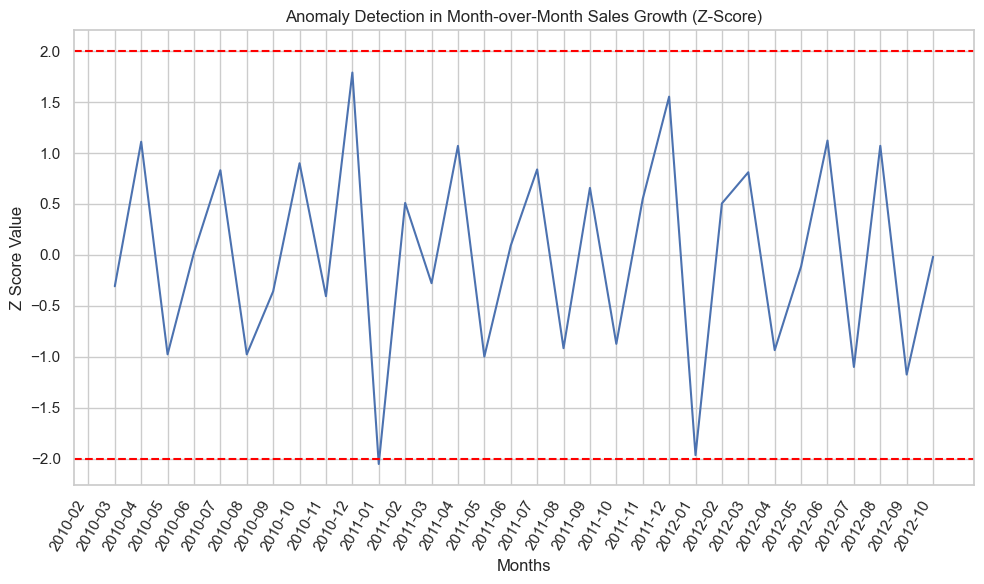

In [63]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data =q4,
    x ='Months',
    y='Z_score'
)
plt.xlabel('Months')
plt.ylabel('Z Score Value')
plt.xticks(rotation =60, ha ='right')
plt.title('Anomaly Detection in Month-over-Month Sales Growth (Z-Score)')
plt.axhline(2, color ='red', linestyle ='--')
plt.axhline(-2, color ='red', linestyle ='--')
plt.tight_layout()
plt.show()

## Q5. How Does Month-over-Month Growth Behave Over Time?

Growth rates are evaluated to determine whether sales momentum is stable,
cyclical, or declining over the observed period.

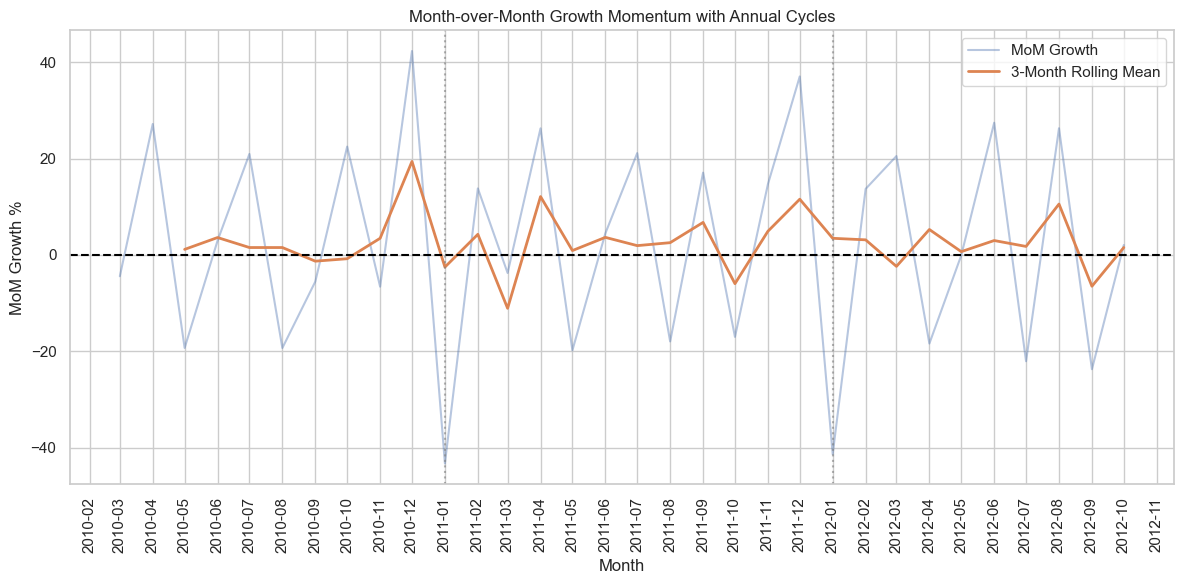

In [64]:
import matplotlib.dates as mdates

q4['Months'] = pd.to_datetime(q4['Months'])
year_starts = q4[q4['Months'].dt.month == 1]['Months']

q4['MoM_Rolling_3M'] = (
    q4['MoM_growth_pct']
    .rolling(window=3)
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    q4['Months'],
    q4['MoM_growth_pct'],
    alpha=0.4,
    label='MoM Growth'
)

plt.plot(
    q4['Months'],
    q4['MoM_Rolling_3M'],
    linewidth=2,
    label='3-Month Rolling Mean'
)

plt.axhline(0, linestyle='--', color='black')

for year in year_starts:
    plt.axvline(year, linestyle=':', color='gray', alpha=0.6)

plt.title('Month-over-Month Growth Momentum with Annual Cycles')
plt.ylabel('MoM Growth %')
plt.xlabel('Month')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

### Insight: Month-over-Month Growth Dynamics

To evaluate sales momentum, we analyzed month-over-month (MoM) growth rates and their rolling averages. While raw MoM growth exhibits short-term volatility, the rolling mean reveals a stable long-run trend with recurring seasonal fluctuations.

Periods of positive and negative growth recur consistently across calendar months, suggesting cyclical demand patterns rather than structural decline. Importantly, the rolling average remains centered near zero without persistent downward drift, indicating that overall momentum has remained stable over time despite short-term shocks.


### Seasonality Assessment
- Monthly averages are compared across years.
- Recurring peaks and troughs are identified and annotated.

---


## Key Findings
*(To be completed after analysis)*

- Summary of major trends
- Seasonal patterns identified
- Notable anomalies or shifts
- Comparison to store-level volatility insights
---

• Sales appear elevated in late-year months, suggesting potential holiday-driven
  demand, though additional years of data would be required to confirm seasonality.



## Implications
- Seasonal sales patterns can inform inventory planning and staffing.
- Aggregate stability suggests diversification benefits across stores.
- Trend shifts may warrant deeper causal investigation.



---

## Deliverables
- Exported time-series dataset (`monthly_sales.csv`)
- Power BI visualizations:
  - Total sales trend
  - Seasonality analysis
  - Growth rate indicators




---

## Next Steps
- Integrate time-series visuals into final dashboard
- Compare trend insights against volatility clusters
- Extend analysis with forecasting models (optional)